This notebook takes the neuron from the previous notebook and expands it to have multiple inputs. It then expands $w$ to contain multiple neurons, making $W$ (a 'number of inputs' x 'number of neurons' sized matrix) Finally, to calculate the many more derivatives, we use backpropagation.

This is a neural network implemented only with NumPy containing 1 hidden layer and 1 output layer, trained using my own backpropagation algorithm, with results visualised through MPL.

In [1]:
#import dependencies
import numpy as np
import matplotlib.pyplot as plt
from numpy import random

### Utilities

In [2]:
def sigmoid(X):
    return 1 / (1 + np.exp(-X))

def sigmoid_param(X, W, b):
    return 1 / (1 + np.exp(-(X @ W.T + b))) 

def binary_cross_entropy(y, A): 
    return - np.mean(
        y * np.log(A) + 
        (1 - y) * np.log(1 - A)
    )

def relu(z):
    return np.maximum(0, z)

def leakyRelu(z):
    return np.maximum(0.01*z, z)

def gelu(z):
    return 0.5 * z * (
            1 + np.tanh(
                np.sqrt(2 / np.pi) * (z + 0.044715 * z**3) # using erf approximation
            )
        )

def neuron_layer_trainer(X, y, lr, W1, b1, W2, b2, epochs):

    loss_tracker = []

    m = X.shape[0] # number of samples

    y = y.reshape(-1,1)

    for epoch in range(epochs):

        # forward
        Z1 = X @ W1.T + b1
        A1 = relu(Z1)
        Z2 = A1 @ W2.T + b2
        A2 = sigmoid(Z2)
    
        loss = binary_cross_entropy(y, A2)

        loss_tracker.append(loss)

        # backward
        # output gradients
        dZ2 = A2 - y

        dW2 = (dZ2.T @ A1) / m
        db2 = (np.sum(dZ2, axis=0, keepdims=True)) / m

        # hidden gradients
        dA1 = dZ2 @ W2
        dZ1 = dA1 * (Z1 > 0)
        
        dW1 = (dZ1.T @ X) / m
        db1 = (np.sum(dZ1, axis=0, keepdims=True)) / m

        # update
        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2

    return W1, b1, W2, b2, loss_tracker    

### Sample data

In [3]:
# Note: inputs are columns to reduce cache misses for faster performance. 
# Hence, X @ W.transpose() calculated instead of W @ X

# columns: hours studied, attendance (/100)

X = np.array([
    [1, 40],
    [2, 50],
    [3, 55],
    [2, 70],
    [4, 75],
    [5, 80],
    [6, 85],
    [7, 90],
    [3, 90],
    [5, 60],
    [4, 65],
    [6, 70]
], dtype=float)

# normalise data for each input [z = (x - mean) / std]
X = (X - X.mean(axis=0)) / X.std(axis=0)

# passed the exam? pass = 1 : fail = 0
y = np.array([
    0,0,0,0,1,1,1,1,0,1,0,1
])

### Build

In [4]:
# starting conditions

rng = np.random.default_rng(21)

learning_rate = 0.1
epochs = 1000

W1_i = rng.normal(0, 0.1, size=(4, 2))
b1_i = np.zeros((1, 4))

W2_i = rng.normal(0, 0.1, size=(1, 4))
b2_i = 0

W1, b1, W2, b2, loss_data = neuron_layer_trainer(X, y, learning_rate, W1_i, b1_i, W2_i, b2_i, epochs)

### Visualisation

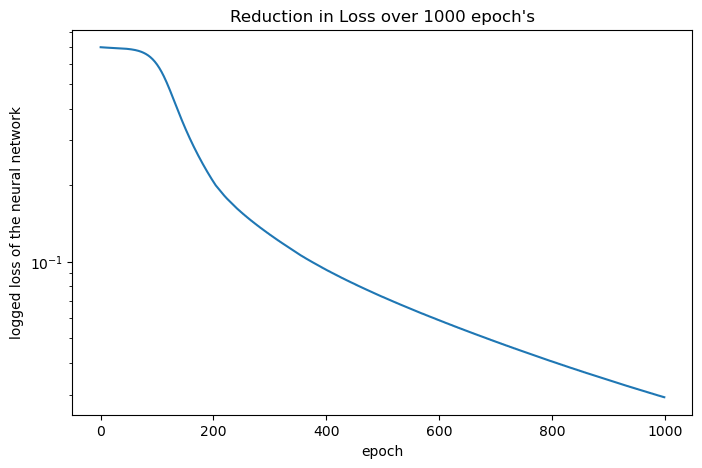

In [5]:
plt.figure(figsize=(8,5))
plt.semilogy(loss_data)
plt.title("Reduction in Loss over 1000 epoch's")
plt.ylabel("logged loss of the neural network")
plt.xlabel("epoch")
plt.show()

In [6]:
def forward(X_i):
    Z1 = X_i @ W1_i.T + b1_i
    A1 = relu(Z1)
    Z2 = A1 @ W2_i.T + b2_i
    A2 = sigmoid(Z2)
    return A2

def plot_decision_boundary(X, y, model):

    x_min, x_max = X[:,0].min() * 1.1, X[:,0].max() * 1.1
    y_min, y_max = X[:,1].min() * 1.1, X[:,1].max() * 1.1

    xx, yy = np.meshgrid(
        np.linspace(x_min,x_max,200),
        np.linspace(y_min,y_max,200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    probs = model(grid)
    probs = probs.reshape(xx.shape)

    plt.contour(
        xx,
        yy,
        probs,
        levels=[0.5]
    )

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y.flatten()
    )

    plt.xlabel("Hours Studied (normalised)")
    plt.ylabel("Attendance (normalised)")
    plt.title("Decision Boundary")

    plt.show()

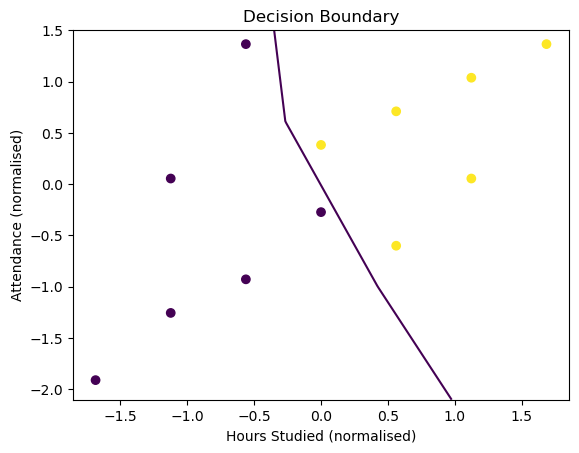

In [7]:
plot_decision_boundary(X, y, forward)